<a href="https://colab.research.google.com/github/narwadeharsh69-a11y/DemoSYBAIDS/blob/main/PracticalNo_08_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nmae : Harsh Narwade

Branch : AI(AI&DS)

Class : Second Year

Div : B  

Roll NO : 62



                                             Practical NO : 08

Aim : Implement and analyze various methods of studying correlation and regression  including Karl Pearson’s coefficient and simple linear regression

Theory :

### 1. What is correlation? How is it different from regression?

**Correlation** is a statistical measure that expresses the extent to which two variables are linearly related (meaning they change together at a constant rate). It's used to quantify the strength and direction of a relationship between two quantitative variables.

*   **Strength**: How closely the points on a scatter plot cluster around a straight line.
*   **Direction**: Whether the variables tend to increase together (positive correlation) or one increases as the other decreases (negative correlation).

The **Pearson product-moment correlation coefficient (r)** is a common measure of correlation. It ranges from -1 to +1, where:
*   `+1` indicates a perfect positive linear relationship.
*   `-1` indicates a perfect negative linear relationship.
*   `0` indicates no linear relationship.

**Regression**, particularly **linear regression**, is a statistical method used to model the relationship between a dependent variable (the one you want to predict) and one or more independent variables (the predictors) by fitting a linear equation to observed data. The primary goal of regression is to predict the value of a dependent variable based on the value of an independent variable.

**Key Differences:**

| Feature           | Correlation                                      | Regression                                                 |
| :---------------- | :----------------------------------------------- | :--------------------------------------------------------- |
| **Purpose**       | Measures the strength and direction of a linear relationship between two variables. | Models the relationship between variables to predict a dependent variable. |
| **Causation**     | Does not imply causation.                      | Can imply causation, though proper experimental design is needed to confirm. |
| **Symmetry**      | Symmetric (correlation of X with Y is same as Y with X). | Asymmetric (predicting Y from X is different from X from Y). |
| **Variables**     | Both variables are typically random.             | Independent variable is fixed or controlled; dependent variable is random. |
| **Output**        | A single value (correlation coefficient).        | An equation (e.g., `y = mx + c`) and a measure of model fit. |


### 2. What is simple linear regression? Explain with a suitable example.

**Simple linear regression** is a statistical model that estimates the relationship between one independent variable (predictor) and one dependent variable (response) using a linear equation. The goal is to find the best-fitting straight line that describes how the dependent variable changes as the independent variable changes.

**The equation for simple linear regression is:**

$y = b_0 + b_1x + \epsilon$

Where:
*   `y` is the **dependent variable** (the outcome you want to predict).
*   `x` is the **independent variable** (the predictor).
*   `b_0` is the **y-intercept** (the value of `y` when `x` is 0).
*   `b_1` is the **slope** of the regression line (the change in `y` for a one-unit change in `x`).
*   `\epsilon` is the **error term** (represents the residual or unexplained variation in `y`).

**Example:**
Imagine a scenario where we want to predict a student's final exam score (dependent variable, `y`) based on the number of hours they studied (independent variable, `x`).

We collect data from several students:

| Hours Studied (x) | Exam Score (y) |
| :---------------- | :------------- |
| 2                 | 60             |
| 3                 | 70             |
| 5                 | 85             |
| 6                 | 90             |
| 8                 | 95             |

Using simple linear regression, we would fit a line to this data. If the resulting equation is, for example, `Exam Score = 50 + 5 * Hours Studied`, this means:
*   A student who studies 0 hours is predicted to score 50 (the y-intercept).
*   For every additional hour studied, the predicted exam score increases by 5 points (the slope).

The regression line minimizes the sum of squared differences between the observed exam scores and the scores predicted by the line (this is called the "least squares" method).


### 4. What is multicollinearity? Does it affect simple regression?

**Multicollinearity** refers to a situation in multiple regression (not simple linear regression) where two or more independent variables are highly correlated with each other. In other words, one predictor variable can be linearly predicted from the others with a substantial degree of accuracy.

**Does it affect simple regression?**

No, multicollinearity **does not directly affect simple linear regression**. Simple linear regression involves only one independent variable. Therefore, by definition, there cannot be a correlation between *multiple* independent variables if there's only one. Multicollinearity is a concern *only* when you have two or more independent variables in a **multiple linear regression** model.

In multiple regression, high multicollinearity can lead to several problems:
*   **Unreliable coefficient estimates**: The coefficients (`b` values) of the correlated variables can be unstable and difficult to interpret.
*   **Inflated standard errors**: This makes it harder to determine the true effect of each independent variable on the dependent variable, as p-values can become misleading.
*   **Difficulty in identifying important predictors**: It becomes challenging to isolate the individual impact of each highly correlated predictor.
*   **Reduced model interpretability**: It's hard to understand how each individual predictor affects the outcome.


### 5. A dataset shows strong correlation but poor prediction accuracy. Why?

There are several reasons why a dataset might exhibit a strong correlation between two variables, yet a linear regression model built on that correlation yields poor prediction accuracy:

1.  **Non-linear Relationship**: The correlation coefficient (like Pearson's r) measures *linear* relationships. If the true relationship between the variables is strong but non-linear (e.g., quadratic, exponential, or sinusoidal), a linear model will fail to capture this underlying pattern, leading to poor predictions despite a high correlation coefficient. The data points might be close to a curve, but not a straight line.

2.  **Outliers and Influential Points**: A few extreme data points (outliers) can heavily influence the correlation coefficient, making it appear stronger than the true relationship for the majority of the data. These outliers can also distort the linear regression line, pulling it away from the main cluster of data, thus leading to poor predictions for most data points.

3.  **High Variance in Data (Large Residuals)**: Even with a strong correlation, there might still be a significant amount of unexplained variance (noise) around the regression line. This means that while there's a general trend, individual data points deviate considerably from the predicted line, leading to large prediction errors. The model might capture the general direction but fail to pinpoint exact values.

4.  **Confounding Variables/Missing Predictors**: The strong correlation observed between two variables might be due to their shared relationship with a third, unobserved, or omitted variable (a confounding variable). A simple linear model using only the two correlated variables might be insufficient because it's missing crucial information that explains the true variance in the dependent variable.

5.  **Small Sample Size**: In small datasets, a strong correlation might appear by chance, but it may not generalize well to the larger population, leading to poor predictive performance on new data.

6.  **Violation of Linear Regression Assumptions**: Linear regression relies on several assumptions (e.g., linearity, independence of errors, homoscedasticity, normality of residuals). If these assumptions are severely violated, even a strong correlation won't lead to an accurate linear model.

In essence, correlation describes the *association*, while prediction accuracy measures how well a model can *forecast* specific values. A strong association doesn't automatically imply a simple linear model is the best or most accurate predictive tool, especially if the relationship isn't truly linear or if other factors are at play.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Set a random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Data Generation for Demonstration
Let's create a synthetic dataset to illustrate correlation and simple linear regression. We'll simulate data for 'Hours Studied' and 'Exam Score'.

,Hours_Studied,Exam_Score
0,3.745401,65.852075
1,9.507143,85.038499
2,7.319939,80.197365
3,5.986585,54.070650
4,1.560186,54.044027


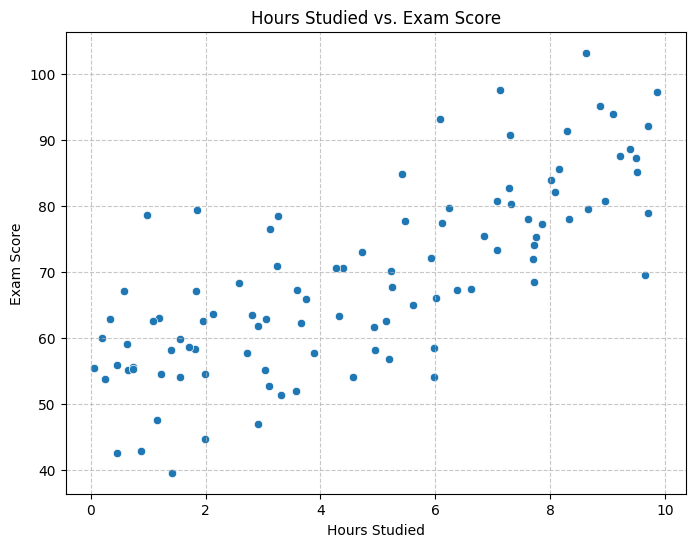

In [ ]:
# Generate synthetic data
hours_studied = np.random.rand(100) * 10 # 0 to 10 hours
exam_score = 50 + (hours_studied * 4) + np.random.randn(100) * 10 # Base score 50, +4 points per hour, with some noise

data = pd.DataFrame({
    'Hours_Studied': hours_studied,
    'Exam_Score': exam_score
})

display(data.head())

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=data)
plt.title('Hours Studied vs. Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 3. How do you calculate Pearson correlation in Python?

We can calculate Karl Pearson's correlation coefficient using `pandas.DataFrame.corr()` or `scipy.stats.pearsonr()`.

In [ ]:
# Method 1: Using pandas .corr()
correlation_matrix = data.corr()
print("Pearson Correlation Matrix:\n", correlation_matrix)

# Extracting the specific correlation value
pearson_corr_pandas = correlation_matrix.loc['Hours_Studied', 'Exam_Score']
print(f"\nPearson correlation between Hours Studied and Exam Score (using pandas): {pearson_corr_pandas:.3f}")

# Method 2: Using scipy.stats.pearsonr
pearson_corr_scipy, p_value = pearsonr(data['Hours_Studied'], data['Exam_Score'])
print(f"Pearson correlation between Hours Studied and Exam Score (using scipy): {pearson_corr_scipy:.3f}")
print(f"P-value: {p_value:.3f}")

Pearson Correlation Matrix:
                Hours_Studied  Exam_Score
Hours_Studied       1.000000    0.759292
Exam_Score          0.759292    1.000000

Pearson correlation between Hours Studied and Exam Score (using pandas): 0.759
Pearson correlation between Hours Studied and Exam Score (using scipy): 0.759
P-value: 0.000


## Simple Linear Regression Implementation

Now, let's implement simple linear regression on our synthetic dataset to predict 'Exam Score' based on 'Hours Studied'.

In [ ]:
# Prepare the data
X = data[['Hours_Studied']] # Independent variable (must be 2D array or DataFrame)
y = data['Exam_Score']     # Dependent variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {len(X_train)} samples")
print(f"Testing data size: {len(X_test)} samples")

# Create a Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Display model coefficients
print(f"\nIntercept (b0): {model.intercept_:.2f}")
print(f"Coefficient (b1) for Hours_Studied: {model.coef_[0]:.2f}")

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Training data size: 80 samples
Testing data size: 20 samples

Intercept (b0): 51.43
Coefficient (b1) for Hours_Studied: 3.60

Mean Squared Error (MSE): 65.37
Root Mean Squared Error (RMSE): 8.09
R-squared (R2): 0.61


### Visualizing the Simple Linear Regression Line

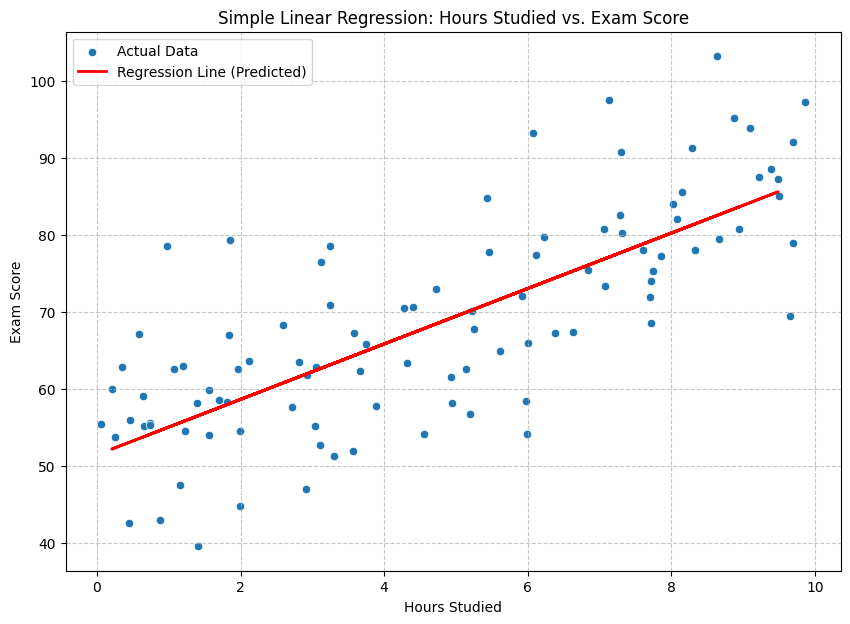

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=data, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line (Predicted)')

plt.title('Simple Linear Regression: Hours Studied vs. Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Example: Strong Correlation, Poor Prediction Accuracy

Let's demonstrate a scenario where variables have a strong correlation, but a simple linear model provides poor prediction accuracy due to a non-linear underlying relationship.

Pearson correlation for non-linear data: -0.030
Mean Squared Error (MSE) for non-linear data with linear model: 53.26
R-squared (R2) for non-linear data with linear model: -0.06


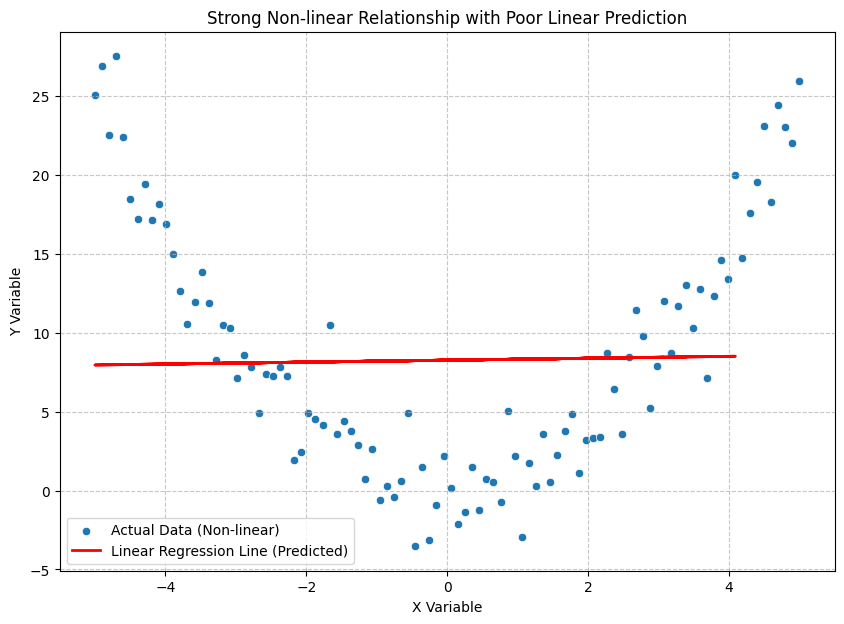

In [ ]:
# Generate data with a strong quadratic relationship + noise
x_nonlinear = np.linspace(-5, 5, 100)
y_nonlinear = x_nonlinear**2 + np.random.randn(100) * 2 # Quadratic relationship with noise

nonlinear_df = pd.DataFrame({
    'X_variable': x_nonlinear,
    'Y_variable': y_nonlinear
})

# Calculate Pearson correlation
pearson_corr_nonlinear, _ = pearsonr(nonlinear_df['X_variable'], nonlinear_df['Y_variable'])
print(f"Pearson correlation for non-linear data: {pearson_corr_nonlinear:.3f}")

# Fit a simple linear regression model
X_nonlin = nonlinear_df[['X_variable']]
y_nonlin = nonlinear_df['Y_variable']

X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(X_nonlin, y_nonlin, test_size=0.2, random_state=42)

linear_model_nl = LinearRegression()
linear_model_nl.fit(X_train_nl, y_train_nl)
y_pred_nl = linear_model_nl.predict(X_test_nl)

mse_nl = mean_squared_error(y_test_nl, y_pred_nl)
r2_nl = r2_score(y_test_nl, y_pred_nl)

print(f"Mean Squared Error (MSE) for non-linear data with linear model: {mse_nl:.2f}")
print(f"R-squared (R2) for non-linear data with linear model: {r2_nl:.2f}")

# Plotting the non-linear data and linear regression line
plt.figure(figsize=(10, 7))
sns.scatterplot(x='X_variable', y='Y_variable', data=nonlinear_df, label='Actual Data (Non-linear)')
plt.plot(X_test_nl, y_pred_nl, color='red', linewidth=2, label='Linear Regression Line (Predicted)')

plt.title('Strong Non-linear Relationship with Poor Linear Prediction')
plt.xlabel('X Variable')
plt.ylabel('Y Variable')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Conclusion

In this practical, we've explored correlation and regression:

*   **Correlation** quantifies the strength and direction of a linear relationship between two variables, measured by Pearson's coefficient (ranging from -1 to +1). We calculated it using both `pandas.corr()` and `scipy.stats.pearsonr()`. A positive value indicates that as one variable increases, the other tends to increase, and vice-versa for a negative value. A value near zero suggests no linear relationship.

*   **Simple Linear Regression** models the linear relationship between one independent and one dependent variable, aiming to predict the dependent variable's value. The model `y = b0 + b1x + epsilon` provides an equation to describe this relationship. We implemented a simple linear regression model, trained it on synthetic data, and visualized the fitted line, along with evaluating its performance using MSE and R-squared.

*   **Multicollinearity** is a phenomenon where independent variables in a *multiple* regression model are highly correlated with each other. It **does not affect simple linear regression** because a simple model only involves one independent variable, thus eliminating the possibility of correlation *between* independent variables.

*   Finally, we saw that a dataset can exhibit a **strong correlation but still lead to poor prediction accuracy with a simple linear model**. This often occurs when the true relationship between variables is non-linear (e.g., quadratic or exponential), even if the data points generally move together. A linear model cannot adequately capture such complexities, resulting in large prediction errors despite an apparent strong association.